In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Binary Labelencode

In [4]:
df["ExerciseAngina"] = df["ExerciseAngina"].map({"N":1,"Y":0})
df["Sex"] = df["Sex"].map({"M":1,"F":0})

# Now Apply Dummiews Method For converting category columns into Numeric 

In [6]:
df = pd.get_dummies(df,columns=["ChestPainType", "RestingECG", "ST_Slope"],drop_first=True,dtype=int)
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,1,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,1,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,1,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,0,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,1,0.0,0,0,1,0,1,0,0,1


# Basic Visualization

In [8]:
df.isnull().sum()

Age                  0
Sex                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
ExerciseAngina       0
Oldpeak              0
HeartDisease         0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

In [9]:
df.shape

(918, 16)

In [10]:
df.dtypes

Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
HeartDisease           int64
ChestPainType_ATA      int32
ChestPainType_NAP      int32
ChestPainType_TA       int32
RestingECG_Normal      int32
RestingECG_ST          int32
ST_Slope_Flat          int32
ST_Slope_Up            int32
dtype: object

In [11]:
df.duplicated().sum()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    int32  
 10  ChestPainType_NAP  918 non-null    int32  
 11  ChestPainType_TA   918 non-null    int32  
 12  RestingECG_Normal  918 non-null    int32  
 13  RestingECG_ST      918 non-null    int32  
 14  ST_Slope_Flat      918 non-null    int32  
 15  ST_Slope_Up        918 non-null    int32  
dtypes: float64(1), int32(7), i

In [13]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.595861,0.887364,0.553377,0.188453,0.221133,0.050109,0.601307,0.193900,0.501089,0.430283
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414,0.391287,0.415236,0.218289,0.489896,0.395567,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,1.000000,0.600000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# split x and y 

In [15]:
x = df.drop("HeartDisease",axis=1)
y = df["HeartDisease"]

# Scale the X column

In [17]:
mm = MinMaxScaler()
x_scale = mm.fit_transform(x)

In [18]:
x_scale.shape

(918, 15)

# Train test and Train model

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x_scale,y,test_size=0.2,random_state=42)

In [22]:
model = RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [23]:
predicted = model.predict(x_test)
print("Accuracy_Score is: ",accuracy_score(predicted,y_test))

Accuracy_Score is:  0.875


In [24]:
print("classification_report: ",classification_report(predicted,y_test))

classification_report:                precision    recall  f1-score   support

           0       0.84      0.86      0.85        76
           1       0.90      0.89      0.89       108

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [25]:
cm = confusion_matrix(predicted,y_test)

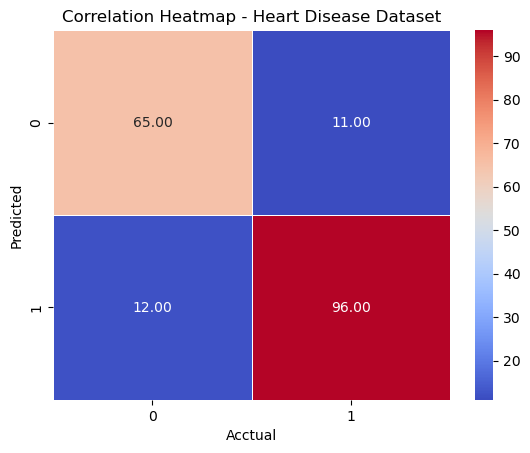

In [26]:
sns.heatmap(cm,annot=True,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Heart Disease Dataset")
plt.xlabel("Acctual")
plt.ylabel("Predicted")
plt.show()

# Save Model

In [61]:
import joblib

joblib.dump(model, "heart_model.pkl")


['heart_model.pkl']